In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier as knn

In [18]:
Data = 'data/data.csv'
df = pd.read_csv(Data, sep=';')

Data_X = df.drop(columns=['Target'])
Data_y = df['Target']

X_train, X_test, y_train, y_test = train_test_split(Data_X, Data_y, test_size=0.2, random_state=42)

In [3]:
Knn_model = knn(n_neighbors=3)


Knn_model.fit(X_train, y_train)
knn_y_pred = Knn_model.predict(X_test)

knn_Accuracy = accuracy_score(y_test, knn_y_pred)
print(f'K-Nearest Neighbour Accuracy: {knn_Accuracy * 100:.2f}%')

K-Nearest Neighbour Accuracy: 59.89%


              precision    recall  f1-score   support

     Dropout       0.62      0.56      0.59       316
    Enrolled       0.31      0.21      0.25       151
    Graduate       0.65      0.77      0.70       418

    accuracy                           0.60       885
   macro avg       0.53      0.51      0.51       885
weighted avg       0.58      0.60      0.58       885



<Axes: >

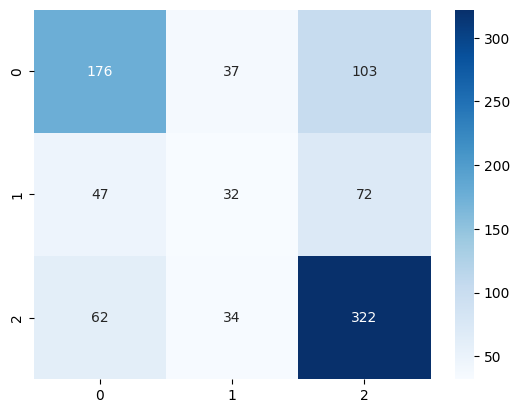

In [4]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print(classification_report(y_test, knn_y_pred))

sns.heatmap(confusion_matrix(y_test, knn_y_pred), annot=True, fmt='d', cmap='Blues')

In [19]:
RandomForest_model = RandomForestClassifier()

RandomForest_model.fit(X_train, y_train)
RandomForest_y_pred = RandomForest_model.predict(X_test)

RandomForest_Accuracy = accuracy_score(y_test, RandomForest_y_pred)
print(f'Random Forest Accuracy: {RandomForest_Accuracy * 100:.2f}%')

Random Forest Accuracy: 76.38%


In [20]:
print(classification_report(y_test, RandomForest_y_pred))

              precision    recall  f1-score   support

     Dropout       0.84      0.76      0.80       316
    Enrolled       0.51      0.32      0.40       151
    Graduate       0.77      0.93      0.84       418

    accuracy                           0.76       885
   macro avg       0.71      0.67      0.68       885
weighted avg       0.75      0.76      0.75       885



In [28]:
# Feature selection
Data_X_features = 'data/data(Some features dropped).csv'
Data_X = pd.read_csv(Data_X_features)
Data_X = Data_X.drop(columns=['Target'])


X_train, X_test, y_train, y_test = train_test_split(Data_X, Data_y, test_size=0.2, random_state=42)

RandomForest_model = RandomForestClassifier()

RandomForest_model.fit(X_train, y_train)
RandomForest_y_pred = RandomForest_model.predict(X_test)

RandomForest_Accuracy = accuracy_score(y_test, RandomForest_y_pred)
print(f'Random Forest (Feature Selection) Accuracy: {RandomForest_Accuracy * 100:.2f}%')

Random Forest (Feature Selection) Accuracy: 77.06%


In [29]:
# Some Features added 
Data_X_features = 'data/data(Some features added).csv'
Data_X = pd.read_csv(Data_X_features)
Data_X = Data_X.drop(columns=['Target'])


X_train, X_test, y_train, y_test = train_test_split(Data_X, Data_y, test_size=0.2, random_state=42)

RandomForest_model = RandomForestClassifier()

RandomForest_model.fit(X_train, y_train)
RandomForest_y_pred = RandomForest_model.predict(X_test)

RandomForest_Accuracy = accuracy_score(y_test, RandomForest_y_pred)
print(f'Random Forest (Some features added) Accuracy: {RandomForest_Accuracy * 100:.2f}%')

Random Forest (Some features added) Accuracy: 77.40%


In [31]:
# Converted to binary data 
Data_X_features = 'data/Binary_data.csv'
Data_X = pd.read_csv(Data_X_features)
Data_y = Data_X['Target']
Data_X = Data_X.drop(columns=['Target'])


X_train, X_test, y_train, y_test = train_test_split(Data_X, Data_y, test_size=0.2, random_state=42)

RandomForest_model = RandomForestClassifier()

RandomForest_model.fit(X_train, y_train)
RandomForest_y_pred = RandomForest_model.predict(X_test)

RandomForest_Accuracy = accuracy_score(y_test, RandomForest_y_pred)
print(f'Random Forest (Binary data) Accuracy: {RandomForest_Accuracy * 100:.2f}%')

Random Forest (Binary data) Accuracy: 90.77%


In [9]:
Data_X.info()

<class 'pandas.DataFrame'>
RangeIndex: 3630 entries, 0 to 3629
Data columns (total 26 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Marital status                          3630 non-null   int64  
 1   Application mode                        3630 non-null   int64  
 2   Course                                  3630 non-null   int64  
 3   Previous qualification                  3630 non-null   int64  
 4   Previous qualification (grade)          3630 non-null   float64
 5   Mother's qualification                  3630 non-null   int64  
 6   Father's qualification                  3630 non-null   int64  
 7   Mother's occupation                     3630 non-null   int64  
 8   Father's occupation                     3630 non-null   int64  
 9   Admission grade                         3630 non-null   float64
 10  Debtor                                  3630 non-null   int64  
 11  Tu

              precision    recall  f1-score   support

     Dropout       0.91      0.84      0.88       277
    Graduate       0.91      0.95      0.93       449

    accuracy                           0.91       726
   macro avg       0.91      0.90      0.90       726
weighted avg       0.91      0.91      0.91       726



<Axes: >

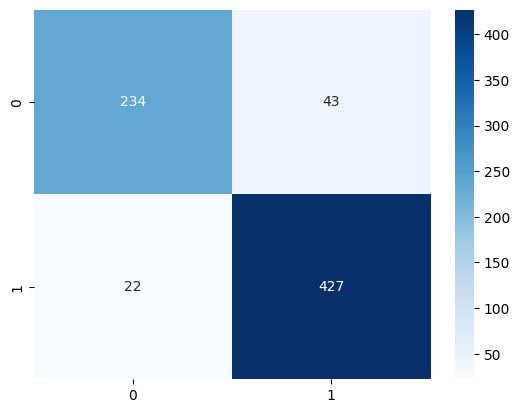

In [10]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print(classification_report(y_test, RandomForest_y_pred))

sns.heatmap(confusion_matrix(y_test, RandomForest_y_pred), annot=True, fmt='d', cmap='Blues')

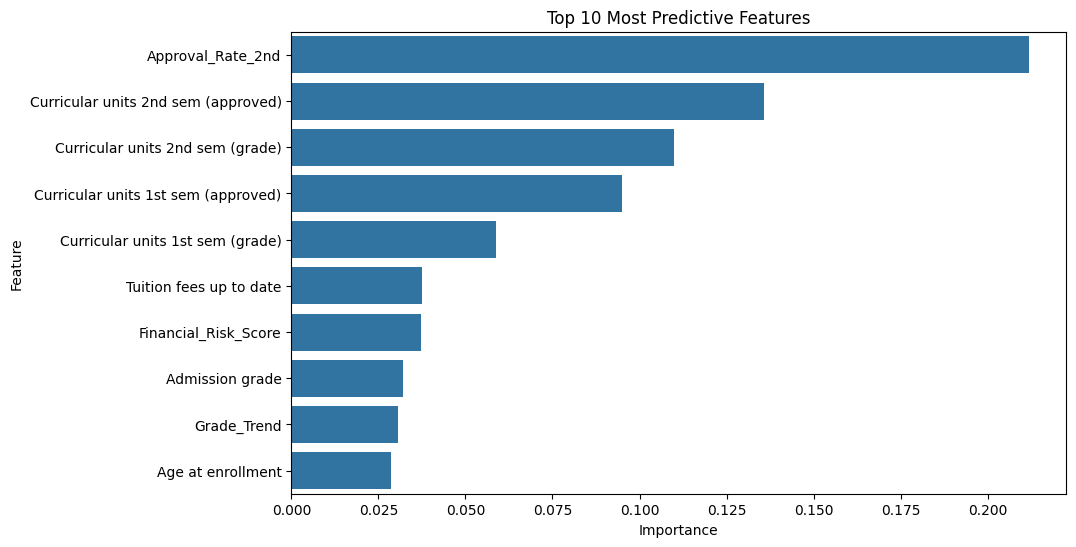

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Get the importance scores
importances = RandomForest_model.feature_importances_

# 2. Match them with your column names
feature_names = X_train.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# 3. Sort by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# 4. Plot the Top 10
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10))
plt.title('Top 10 Most Predictive Features')
plt.show()

In [12]:
# Isolate the students the model got wrong
y_pred = RandomForest_model.predict(X_test)
errors = X_test[y_test != y_pred].copy()
errors['Actual'] = y_test[y_test != y_pred]

# Compare 'Missed' students to 'All' students
print("--- Mean Age Comparison ---")
print(f"Dataset Average Age: {Data_X['Age at enrollment'].mean():.2f}")
print(f"Incorrectly Predicted Students Average Age: {errors['Age at enrollment'].mean():.2f}")

# Check if a specific course is causing the most errors
print("\n--- Error Rate by Course ---")
print(errors['Course'].value_counts(normalize=True).head())

--- Mean Age Comparison ---
Dataset Average Age: 23.46
Incorrectly Predicted Students Average Age: 23.48

--- Error Rate by Course ---
Course
9500    0.169231
9991    0.138462
9070    0.092308
9773    0.092308
9238    0.076923
Name: proportion, dtype: float64


In [ ]:
# Parameter optimization using optuna

import optuna

def objective(trial):
    n_estimators = trial.suggest_int('n_estimators', 50, 500)
    max_depth = trial.suggest_int('max_depth', 3, 20)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 20)
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2'])

    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        random_state=42
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return accuracy_score(y_test, y_pred)

/home/bbo/Documents/Code/projects/dropout-risk-factor-analysis/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [14]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)

print("Best accuracy:", study.best_value)
print("Best parameters:", study.best_params)

[I 2026-05-14 10:41:52,230] A new study created in memory with name: no-name-8aa40a19-c6fd-4d05-92ca-305fad1e878c
[I 2026-05-14 10:41:53,145] Trial 0 finished with value: 0.9022038567493113 and parameters: {'n_estimators': 73, 'max_depth': 9, 'min_samples_split': 12, 'min_samples_leaf': 9, 'max_features': 'log2'}. Best is trial 0 with value: 0.9022038567493113.
[I 2026-05-14 10:41:56,701] Trial 1 finished with value: 0.9035812672176309 and parameters: {'n_estimators': 342, 'max_depth': 19, 'min_samples_split': 16, 'min_samples_leaf': 15, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.9035812672176309.
[I 2026-05-14 10:42:01,065] Trial 2 finished with value: 0.9077134986225895 and parameters: {'n_estimators': 432, 'max_depth': 8, 'min_samples_split': 11, 'min_samples_leaf': 6, 'max_features': 'sqrt'}. Best is trial 2 with value: 0.9077134986225895.
[I 2026-05-14 10:42:04,961] Trial 3 finished with value: 0.9049586776859504 and parameters: {'n_estimators': 444, 'max_depth': 8, 'm

Best accuracy: 0.9118457300275482
Best parameters: {'n_estimators': 235, 'max_depth': 10, 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'sqrt'}


/tmp/ipykernel_5893/1496092837.py:1: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_optimization_history(study)


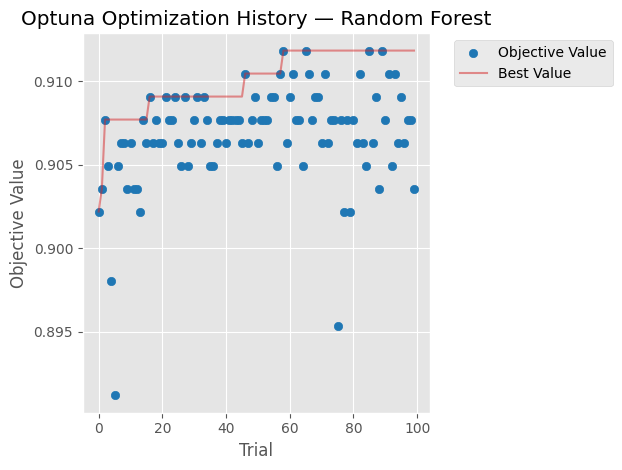

In [15]:
optuna.visualization.matplotlib.plot_optimization_history(study)

plt.title('Optuna Optimization History — Random Forest')
plt.tight_layout()
plt.savefig('optuna_history.png', dpi=200, bbox_inches='tight')
plt.show()